<a href="https://colab.research.google.com/github/quantumomega/ITESM/blob/reto-vacunacion/DS_C2_SC2_RicardoOlveraRamirez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Reto - Análisis del progreso mundial de vacunación

Introducción:



La pandemia por el virus COVID-19 ha provocado grandes cambios en nuestra forma de vida, desde el modo en que interactuamos con nuestros familiares, hasta cómo desempeñamos las labores cotidianas. Por ello, es de gran importancia dar seguimiento puntual al proceso de vacunación en todos los países del mundo, ya que esto contribuirá a desarrollar inmunidad colectiva, evitar pérdidas humanas, liberar los sistemas sanitarios y recuperar las economías debilitadas. Las vacunas son hoy una esperanza próxima de recuperar la confianza de interactuar con el mundo de nuevo.



Debido a este contexto, continuarás trabajando con datos relacionados con el virus COVID-19, analizarás información relacionada con la aplicación de todas las vacunas en el mundo, en un periodo de tiempo específico. Los datos originales se encuentran en el repositorio Our World in Data de GitHub, y en ellos se registra la cantidad de inoculaciones diarias con las vacunas por país.



Utilizarás una muestra reciente del archivo, disponible en el portal kaggle.com. Tu trabajo consiste en recuperar dicha información, seleccionarla, procesarla, obtener resúmenes significativos y precisos, para finalmente almacenar los resultados obtenidos.



Objetivos:



Mediante el análisis, desarrollo y solución de este reto cumplirás los siguientes objetivos:

Emplear los conocimientos adquiridos para obtener información a partir de grandes volúmenes de datos que describen una situación real.
Construir scripts en Python, incluyendo las plataformas NumPy y pandas, para recuperar información en formato tabular de un archivo, seleccionar información relevante y generar nuevos datos o resúmenes que puedan ser almacenados en un archivo de salida.  
Resolver un problema sintetizando datos para obtener resultados concluyentes.

### a)Extraer la información del archivo.

In [3]:


import pandas as pd
CSV_PATH = "/content/country_vaccinations.csv"
df = pd.read_csv(CSV_PATH)
print("Shape (filas, columnas):", df.shape)

Shape (filas, columnas): (86512, 15)


In [4]:
print("Columnas detectadas:\n", list(df.columns))

Columnas detectadas:
 ['country', 'iso_code', 'date', 'total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated', 'daily_vaccinations_raw', 'daily_vaccinations', 'total_vaccinations_per_hundred', 'people_vaccinated_per_hundred', 'people_fully_vaccinated_per_hundred', 'daily_vaccinations_per_million', 'vaccines', 'source_name', 'source_website']


In [5]:
from IPython.display import display
nulls = df.isna().sum().sort_values(ascending=False)
display(nulls.head(10).to_frame("nulos"))

,nulos
daily_vaccinations_raw,51150
people_fully_vaccinated,47710
people_fully_vaccinated_per_hundred,47710
people_vaccinated_per_hundred,45218
people_vaccinated,45218
total_vaccinations,42905
total_vaccinations_per_hundred,42905
daily_vaccinations_per_million,299
daily_vaccinations,299
date,0


###b) Mostrar la estructura y tipos de datos de cada columna para identificar qué operaciones puedes realizar con cada una de ellas, asegurándote que las columnas con fechas sean del tipo datetime64.

In [7]:


print("Estructura del DataFrame:")
print("Filas:", df.shape[0], "| Columnas:", df.shape[1])

print("\nTipos de datos (dtypes):")
print(df.dtypes)

Estructura del DataFrame:
Filas: 86512 | Columnas: 15

Tipos de datos (dtypes):
country                                 object
iso_code                                object
date                                    object
total_vaccinations                     float64
people_vaccinated                      float64
people_fully_vaccinated                float64
daily_vaccinations_raw                 float64
daily_vaccinations                     float64
total_vaccinations_per_hundred         float64
people_vaccinated_per_hundred          float64
people_fully_vaccinated_per_hundred    float64
daily_vaccinations_per_million         float64
vaccines                                object
source_name                             object
source_website                          object
dtype: object


In [8]:
if "date" in df.columns:
    print("Fecha mínima:", df["date"].min())
    print("Fecha máxima:", df["date"].max())

Fecha mínima: 2020-12-02
Fecha máxima: 2022-03-29


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86512 entries, 0 to 86511
Data columns (total 15 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   country                              86512 non-null  object 
 1   iso_code                             86512 non-null  object 
 2   date                                 86512 non-null  object 
 3   total_vaccinations                   43607 non-null  float64
 4   people_vaccinated                    41294 non-null  float64
 5   people_fully_vaccinated              38802 non-null  float64
 6   daily_vaccinations_raw               35362 non-null  float64
 7   daily_vaccinations                   86213 non-null  float64
 8   total_vaccinations_per_hundred       43607 non-null  float64
 9   people_vaccinated_per_hundred        41294 non-null  float64
 10  people_fully_vaccinated_per_hundred  38802 non-null  float64
 11  daily_vaccinations_per_milli

###c. Determinar la cantidad de vacunas aplicadas de cada compañía (con base en cómo lo reporta cada país en la columna vaccines, en otras palabras, agrupe por vaccines y realice la sumatoria).


In [10]:
print("Columnas disponibles:", df.columns.tolist())

Columnas disponibles: ['country', 'iso_code', 'date', 'total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated', 'daily_vaccinations_raw', 'daily_vaccinations', 'total_vaccinations_per_hundred', 'people_vaccinated_per_hundred', 'people_fully_vaccinated_per_hundred', 'daily_vaccinations_per_million', 'vaccines', 'source_name', 'source_website']


In [13]:
if "total_vaccinations" in df.columns and "vaccines" in df.columns:
    vacunas_agrupadas = (
        df.groupby("vaccines")["total_vaccinations"]
          .sum()
          .sort_values(ascending=False)
    )


    vacunas_agrupadas_mill = (vacunas_agrupadas / 1_000_000).round(2)

    display(vacunas_agrupadas_mill.to_frame("total_vac_millones"))
else:
    print("No se encontraron las columnas necesarias ('vaccines' y 'total_vaccinations').")

,total_vac_millones
vaccines,
"CanSino, Sinopharm/Beijing, Sinopharm/Wuhan, Sinovac, ZF2001",709452.66
"Covaxin, Oxford/AstraZeneca, Sputnik V",323440.31
"Johnson&Johnson, Moderna, Pfizer/BioNTech",161757.64
"Moderna, Oxford/AstraZeneca, Pfizer/BioNTech",115391.28
"Johnson&Johnson, Moderna, Oxford/AstraZeneca, Pfizer/BioNTech",99625.79
...,...
"Pfizer/BioNTech, Sinopharm/Beijing, Sputnik V",6.92
"Oxford/AstraZeneca, Pfizer/BioNTech, Sputnik V",6.84
Moderna,6.53


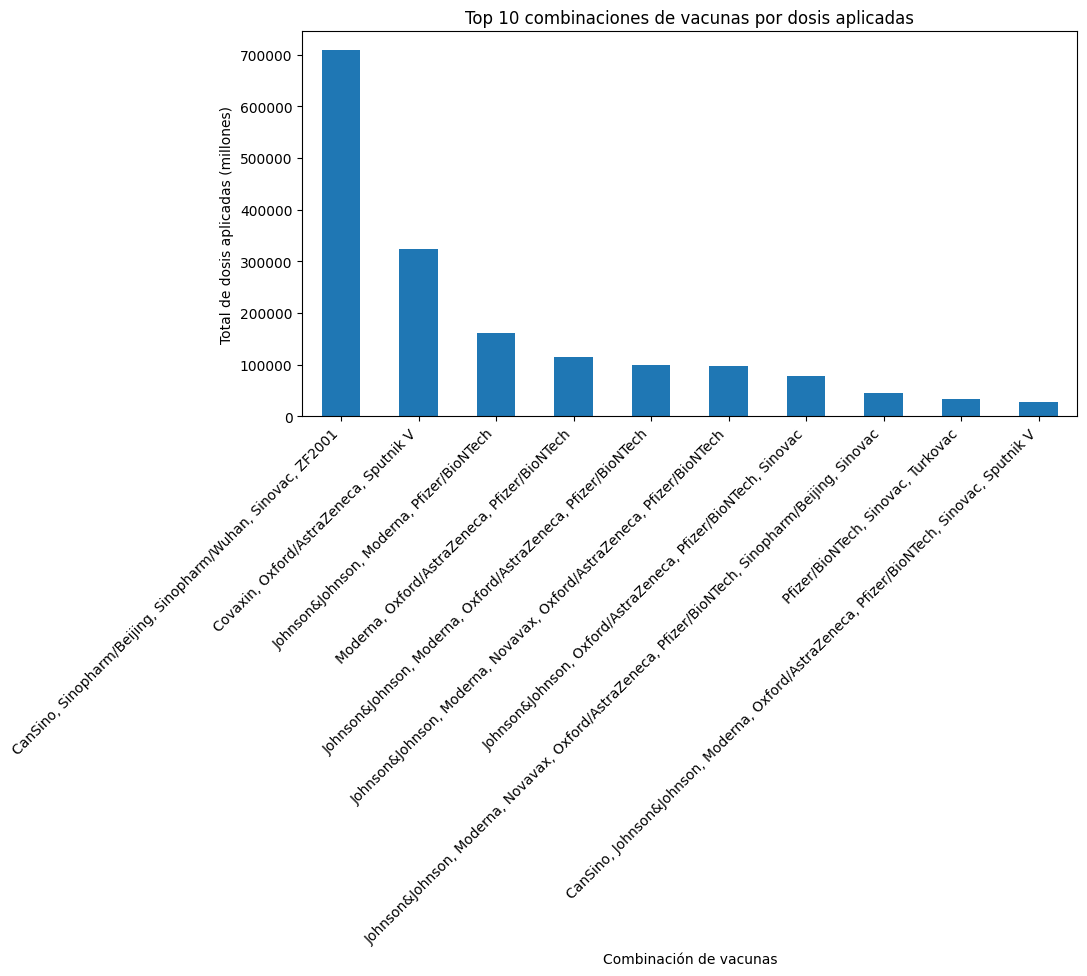

In [14]:
import matplotlib.pyplot as plt

vacunas_agrupadas_mill.head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top 10 combinaciones de vacunas por dosis aplicadas")
plt.ylabel("Total de dosis aplicadas (millones)")
plt.xlabel("Combinación de vacunas")
plt.xticks(rotation=45, ha="right")
plt.show()

###d. Obtener la cantidad de vacunas aplicadas en todo el mundo.

In [17]:

if "total_vaccinations" in df.columns:
    total_mundial = df["total_vaccinations"].sum()

    print("Cantidad total de vacunas aplicadas en el mundo:")
    print(f"{total_mundial:,.0f} dosis")

else:
    print("No se encontró la columna 'total_vaccinations'.")

Cantidad total de vacunas aplicadas en el mundo:
2,002,854,013,761 dosis


###e. Calcular el promedio de vacunas aplicadas por país.

In [19]:


if "total_vaccinations" in df.columns and "country" in df.columns:
    # Promedio global directo
    total_global = df["total_vaccinations"].sum()
    num_paises = df["country"].nunique()
    promedio_global = total_global / num_paises

    print("Promedio de vacunas aplicadas por país (global):")
    print(f"{promedio_global:,.0f} dosis")


    # Promedio del total aplicado por cada país
    vacunas_por_pais = df.groupby("country")["total_vaccinations"].sum()
    promedio_por_pais = vacunas_por_pais.mean()

    print("Promedio de vacunas aplicadas considerando cada país (media de sus totales):")
    print(f"{promedio_por_pais:,.0f} dosis")

else:
    print("No se encontraron las columnas necesarias ('country' y 'total_vaccinations').")

Promedio de vacunas aplicadas por país (global):
8,981,408,133 dosis
Promedio de vacunas aplicadas considerando cada país (media de sus totales):
8,981,408,133 dosis


###f. Determinar la cantidad de vacunas aplicadas el día 29/01/21 en todo el mundo.

In [20]:


if "date" in df.columns and "total_vaccinations" in df.columns:

    fecha = pd.to_datetime("2021-01-29")
    df_dia = df[df["date"] == fecha]


    total_dia = df_dia["total_vaccinations"].sum()

    print(f"Vacunas aplicadas en el mundo el {fecha.date()}:")
    print(f"{total_dia:,.0f} dosis")

else:
    print("No se encuentran las columnas 'date' y 'total_vaccinations'.")

Vacunas aplicadas en el mundo el 2021-01-29:
0 dosis


###g. Crear un dataframe nuevo denominado conDiferencias que contenga los datos originales y una columna derivada (diferencias) con las diferencias de aplicación entre las columnas daily_vaccionations y daily_vaccionations_raw.  

In [21]:


if "daily_vaccinations" in df.columns and "daily_vaccinations_raw" in df.columns:
    conDiferencias = df.copy()


    conDiferencias["diferencias"] = (
        conDiferencias["daily_vaccinations"] - conDiferencias["daily_vaccinations_raw"]
    )


    display(conDiferencias[["country", "date", "daily_vaccinations",
                            "daily_vaccinations_raw", "diferencias"]].head(10))
else:
    print("No se encontraron las columnas 'daily_vaccinations' y 'daily_vaccinations_raw'.")

,country,date,daily_vaccinations,daily_vaccinations_raw,diferencias
0,Afghanistan,2021-02-22,NaN,NaN,NaN
1,Afghanistan,2021-02-23,1367.0,NaN,NaN
2,Afghanistan,2021-02-24,1367.0,NaN,NaN
3,Afghanistan,2021-02-25,1367.0,NaN,NaN
4,Afghanistan,2021-02-26,1367.0,NaN,NaN
5,Afghanistan,2021-02-27,1367.0,NaN,NaN
6,Afghanistan,2021-02-28,1367.0,NaN,NaN
7,Afghanistan,2021-03-01,1580.0,NaN,NaN
8,Afghanistan,2021-03-02,1794.0,NaN,NaN
9,Afghanistan,2021-03-03,2008.0,NaN,NaN


###h. Obtener el periodo de tiempo entre el registro con fecha más reciente y el registro con fecha más antigua.

In [22]:

if "date" in df.columns:

    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    fecha_min = df["date"].min()
    fecha_max = df["date"].max()


    periodo = fecha_max - fecha_min

    print("Fecha más antigua:", fecha_min.date())
    print("Fecha más reciente:", fecha_max.date())
    print(f"Periodo total: {periodo.days} días")
    print(f"Equivalente a ~{periodo.days/30:.1f} meses o ~{periodo.days/365:.2f} años")
else:
    print("No se encontró la columna 'date'.")

Fecha más antigua: 2020-12-02
Fecha más reciente: 2022-03-29
Periodo total: 482 días
Equivalente a ~16.1 meses o ~1.32 años


###i. Crear un dataframe nuevo denominado conCantidad que contenga los datos originales y una columna derivada (canVac) con la cantidad de vacunas utilizadas cada día (usar la columna vaccines y separar por el carácter , ).

In [23]:

if "vaccines" in df.columns:
    conCantidad = df.copy()

    # Calcular el número de vacunas distintas en cada registro
    conCantidad["canVac"] = conCantidad["vaccines"].apply(
        lambda x: len(str(x).split(",")) if pd.notna(x) else 0
    )

    # Mostrar primeras filas como verificación
    display(conCantidad[["country", "date", "vaccines", "canVac"]].head(10))
else:
    print("No se encontró la columna 'vaccines'.")


,country,date,vaccines,canVac
0,Afghanistan,2021-02-22,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",4
1,Afghanistan,2021-02-23,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",4
2,Afghanistan,2021-02-24,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",4
3,Afghanistan,2021-02-25,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",4
4,Afghanistan,2021-02-26,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",4
5,Afghanistan,2021-02-27,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",4
6,Afghanistan,2021-02-28,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",4
7,Afghanistan,2021-03-01,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",4
8,Afghanistan,2021-03-02,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",4
9,Afghanistan,2021-03-03,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",4


###j. Generar un dataframe denominado antes20 con todos los registros que se hayan realizado antes del 20 de diciembre de 2020.

In [26]:

if "date" in df.columns:

    df["date"] = pd.to_datetime(df["date"], errors="coerce")


    fecha_corte = pd.to_datetime("2020-12-20")
    antes20 = df[df["date"] < fecha_corte].copy()

    print("Registros encontrados:", len(antes20))
    print("Rango de fechas en 'antes20':", antes20["date"].min().date(), "→", antes20["date"].max().date())


    display(antes20.head(10))
else:
    print("No se encontró la columna 'date'.")

Registros encontrados: 70
Rango de fechas en 'antes20': 2020-12-02 → 2020-12-19


,country,iso_code,date,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations_raw,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,daily_vaccinations_per_million,vaccines,source_name,source_website
13403,Canada,CAN,2020-12-14,5.0,5.0,NaN,NaN,NaN,0.00,0.00,NaN,NaN,"Johnson&Johnson, Moderna, Oxford/AstraZeneca, ...",Official data from provinces via covid19tracke...,https://covid19tracker.ca/vaccinationtracker.html
13404,Canada,CAN,2020-12-15,727.0,727.0,NaN,722.0,722.0,0.00,0.00,NaN,19.0,"Johnson&Johnson, Moderna, Oxford/AstraZeneca, ...",Official data from provinces via covid19tracke...,https://covid19tracker.ca/vaccinationtracker.html
13405,Canada,CAN,2020-12-16,3025.0,3025.0,NaN,2298.0,1510.0,0.01,0.01,NaN,40.0,"Johnson&Johnson, Moderna, Oxford/AstraZeneca, ...",Official data from provinces via covid19tracke...,https://covid19tracker.ca/vaccinationtracker.html
13406,Canada,CAN,2020-12-17,7279.0,7279.0,NaN,4254.0,2425.0,0.02,0.02,NaN,64.0,"Johnson&Johnson, Moderna, Oxford/AstraZeneca, ...",Official data from provinces via covid19tracke...,https://covid19tracker.ca/vaccinationtracker.html
13407,Canada,CAN,2020-12-18,11296.0,11296.0,NaN,4017.0,2823.0,0.03,0.03,NaN,74.0,"Johnson&Johnson, Moderna, Oxford/AstraZeneca, ...",Official data from provinces via covid19tracke...,https://covid19tracker.ca/vaccinationtracker.html
13408,Canada,CAN,2020-12-19,12367.0,12367.0,NaN,1071.0,2472.0,0.03,0.03,NaN,65.0,"Johnson&Johnson, Moderna, Oxford/AstraZeneca, ...",Official data from provinces via covid19tracke...,https://covid19tracker.ca/vaccinationtracker.html
15756,China,CHN,2020-12-15,1500000.0,NaN,NaN,NaN,NaN,0.10,NaN,NaN,NaN,"CanSino, Sinopharm/Beijing, Sinopharm/Wuhan, S...",National Health Commission,http://www.nhc.gov.cn/jkj/s7915/202203/d81d339...
15757,China,CHN,2020-12-16,NaN,NaN,NaN,NaN,187500.0,NaN,NaN,NaN,130.0,"CanSino, Sinopharm/Beijing, Sinopharm/Wuhan, S...",National Health Commission,http://www.nhc.gov.cn/jkj/s7915/202203/d81d339...
15758,China,CHN,2020-12-17,NaN,NaN,NaN,NaN,187500.0,NaN,NaN,NaN,130.0,"CanSino, Sinopharm/Beijing, Sinopharm/Wuhan, S...",National Health Commission,http://www.nhc.gov.cn/jkj/s7915/202203/d81d339...
15759,China,CHN,2020-12-18,NaN,NaN,NaN,NaN,187500.0,NaN,NaN,NaN,130.0,"CanSino, Sinopharm/Beijing, Sinopharm/Wuhan, S...",National Health Commission,http://www.nhc.gov.cn/jkj/s7915/202203/d81d339...


###k. Obtener un dataframe denominado pfizer con todos los registros donde se haya utilizado la vacuna Pfizer.

In [27]:

if "vaccines" in df.columns:
    pfizer = df[df["vaccines"].str.contains("Pfizer", case=False, na=False)].copy()

    print("Registros encontrados con Pfizer:", len(pfizer))
    print("Rango de fechas en 'pfizer':", pfizer["date"].min().date(), "→", pfizer["date"].max().date())


    display(pfizer.head(10))
else:
    print("No se encontró la columna 'vaccines'.")

Registros encontrados con Pfizer: 64193
Rango de fechas en 'pfizer': 2020-12-02 → 2022-03-29


,country,iso_code,date,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations_raw,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,daily_vaccinations_per_million,vaccines,source_name,source_website
0,Afghanistan,AFG,2021-02-22,0.0,0.0,NaN,NaN,NaN,0.00,0.00,NaN,NaN,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
1,Afghanistan,AFG,2021-02-23,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
2,Afghanistan,AFG,2021-02-24,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
3,Afghanistan,AFG,2021-02-25,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
4,Afghanistan,AFG,2021-02-26,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
5,Afghanistan,AFG,2021-02-27,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
6,Afghanistan,AFG,2021-02-28,8200.0,8200.0,NaN,NaN,1367.0,0.02,0.02,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
7,Afghanistan,AFG,2021-03-01,NaN,NaN,NaN,NaN,1580.0,NaN,NaN,NaN,40.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
8,Afghanistan,AFG,2021-03-02,NaN,NaN,NaN,NaN,1794.0,NaN,NaN,NaN,45.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
9,Afghanistan,AFG,2021-03-03,NaN,NaN,NaN,NaN,2008.0,NaN,NaN,NaN,50.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/


###l. Almacenar los dataframes generados (conDiferencias, conCantidad, antes20 y pfizer) en un archivo de Excel denominado resultadosReto.xlsx, donde cada dataframe ocupe una hoja diferente. Se recomienda ver la documentación de pd.ExcelWriter.

In [28]:



objetos = {
    "conDiferencias": "conDiferencias" in locals(),
    "conCantidad": "conCantidad" in locals(),
    "antes20": "antes20" in locals(),
    "pfizer": "pfizer" in locals(),
}
print("Disponibilidad de DataFrames:", objetos)


with pd.ExcelWriter("resultadosReto.xlsx", engine="openpyxl") as writer:
    if "conDiferencias" in locals():
        conDiferencias.to_excel(writer, sheet_name="conDiferencias", index=False)
    if "conCantidad" in locals():
        conCantidad.to_excel(writer, sheet_name="conCantidad", index=False)
    if "antes20" in locals():
        antes20.to_excel(writer, sheet_name="antes20", index=False)
    if "pfizer" in locals():
        pfizer.to_excel(writer, sheet_name="pfizer", index=False)

print("Archivo 'resultadosReto.xlsx' generado correctamente")

Disponibilidad de DataFrames: {'conDiferencias': True, 'conCantidad': True, 'antes20': True, 'pfizer': True}
Archivo 'resultadosReto.xlsx' generado correctamente
